In [4]:
import earthpy as et
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Download example data
data = et.data.get_data("cold-springs-fire")

# First, let's check the actual directory structure
print("Data directory contents:")
print(os.listdir(data))

# The file might be in a different location. Let's try to find it
# You might need to adjust this path based on the actual directory structure
possible_paths = [
    os.path.join(data, "modis_lst_example.csv"),
    os.path.join(data, "outputs", "modis_lst_example.csv"),
    os.path.join(data, "data", "modis_lst_example.csv"),
]

# Try different possible paths
lst_path = None
for path in possible_paths:
    if os.path.exists(path):
        lst_path = path
        break

if lst_path is None:
    print("Could not find the MODIS LST data file. Please check the file structure.")
else:
    # Load the dataset
    df = pd.read_csv(lst_path)
    # Convert the `date` column to a datetime object
    df["date"] = pd.to_datetime(df["date"])
    # Display the first few rows
    print("\nDataset head:")
    print(df.head())

Data directory contents:
['landsat_collect', 'vector_layers', 'outputs', 'modis', 'readme.txt', 'naip']
Could not find the MODIS LST data file. Please check the file structure.


In [5]:
plt.figure(figsize=(10, 6))
plt.plot(df["date"], df["temperature"], label="Land Surface Temperature")
plt.title("Land Surface Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.savefig("land_surface_temperature_over_time.png")
plt.show()

NameError: name 'df' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Set the date column as the index for decomposition
df.set_index("date", inplace=True)
# Perform seasonal decomposition
result = seasonal_decompose(df["temperature"], model="additive", period=365)
# Plot the decomposition
result.plot()
plt.savefig("seasonal_decomposition.png")
plt.show()

# Calculate rolling mean and standard deviation
rolling_mean = df["temperature"].rolling(window=30).mean()
rolling_std = df["temperature"].rolling(window=30).std()
# Identify anomalies
anomalies = df[
    (df["temperature"] > rolling_mean + 2 * rolling_std)
    | (df["temperature"] < rolling_mean - 2 * rolling_std)
]
# Plot anomalies
plt.figure(figsize=(10, 6))
plt.plot(df.index, df["temperature"], label="Temperature")
plt.scatter(anomalies.index, anomalies["temperature"], color="red", label="Anomalies")
plt.title("Temperature Anomalies")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.savefig("temperature_anomalies.png")
plt.show()

from statsmodels.tsa.arima.model import ARIMA

# Fit an ARIMA model
model = ARIMA(df["temperature"], order=(5, 1, 0))
fit = model.fit()
# Forecast future temperatures
forecast = fit.forecast(steps=365)
# Plot the forecast
plt.figure(figsize=(10, 6))
plt.plot(df.index, df["temperature"], label="Historical Temperature")
plt.plot(pd.date_range(df.index[-1], periods=365, freq="D"), forecast, label="Forecast")
plt.title("Temperature Forecast")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.savefig("temperature_forecast.png")
plt.show()

In [2]:
!pip install earthpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 12.7 MB/s eta 0:00:00


Loading and processing data...
Fitting SARIMA model...
RMSE: 210.63


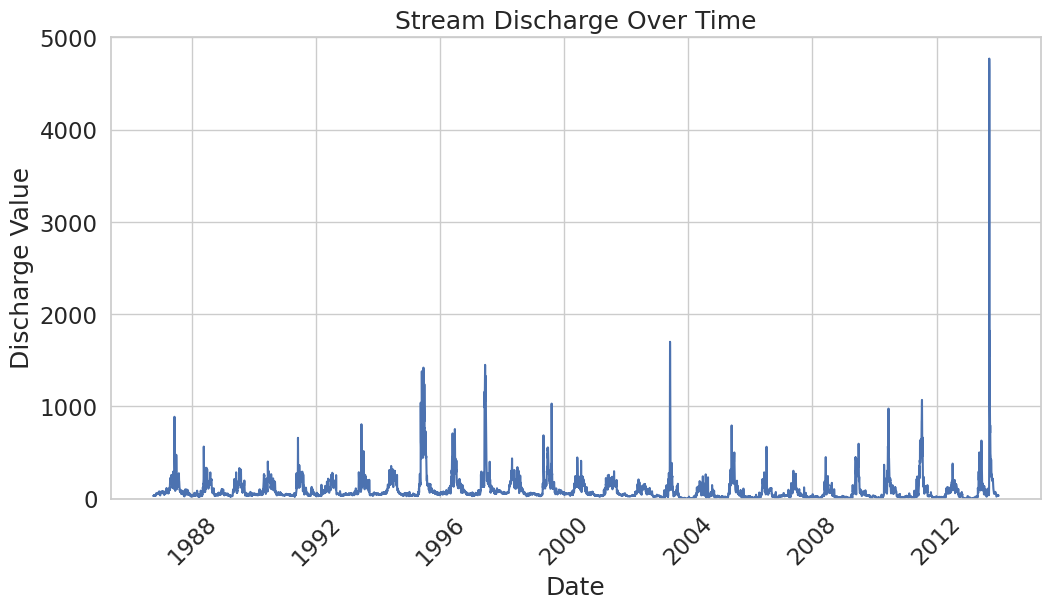

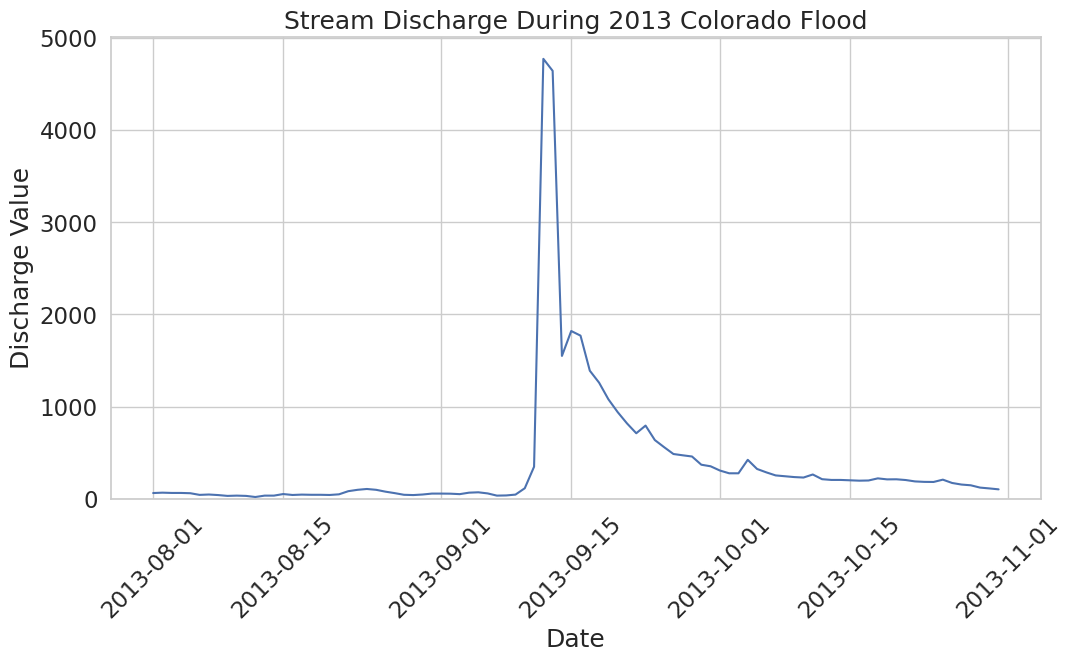

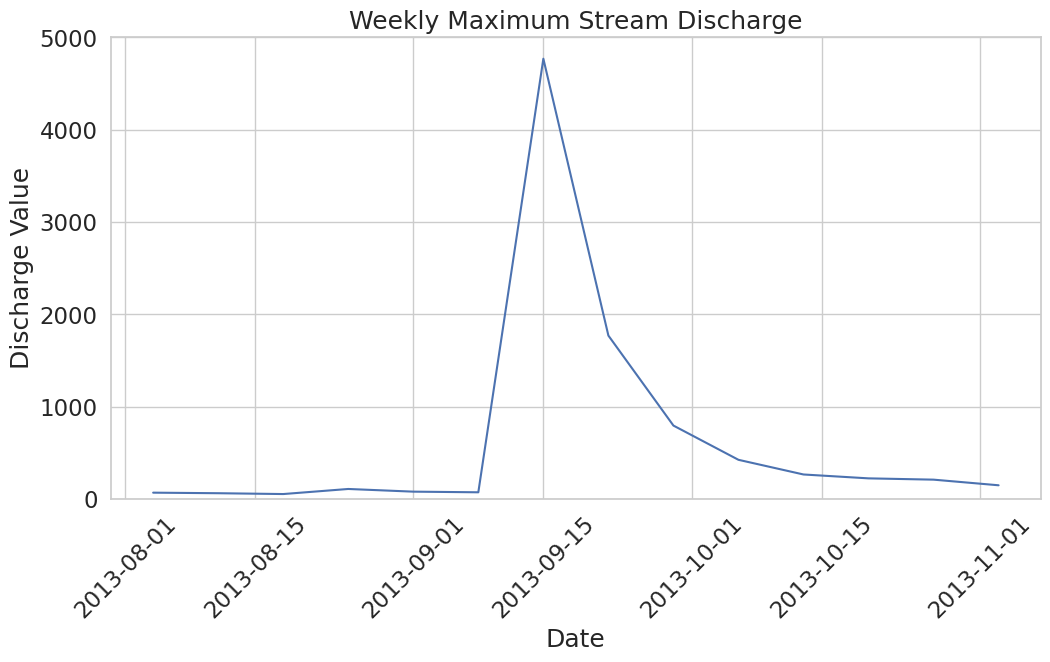

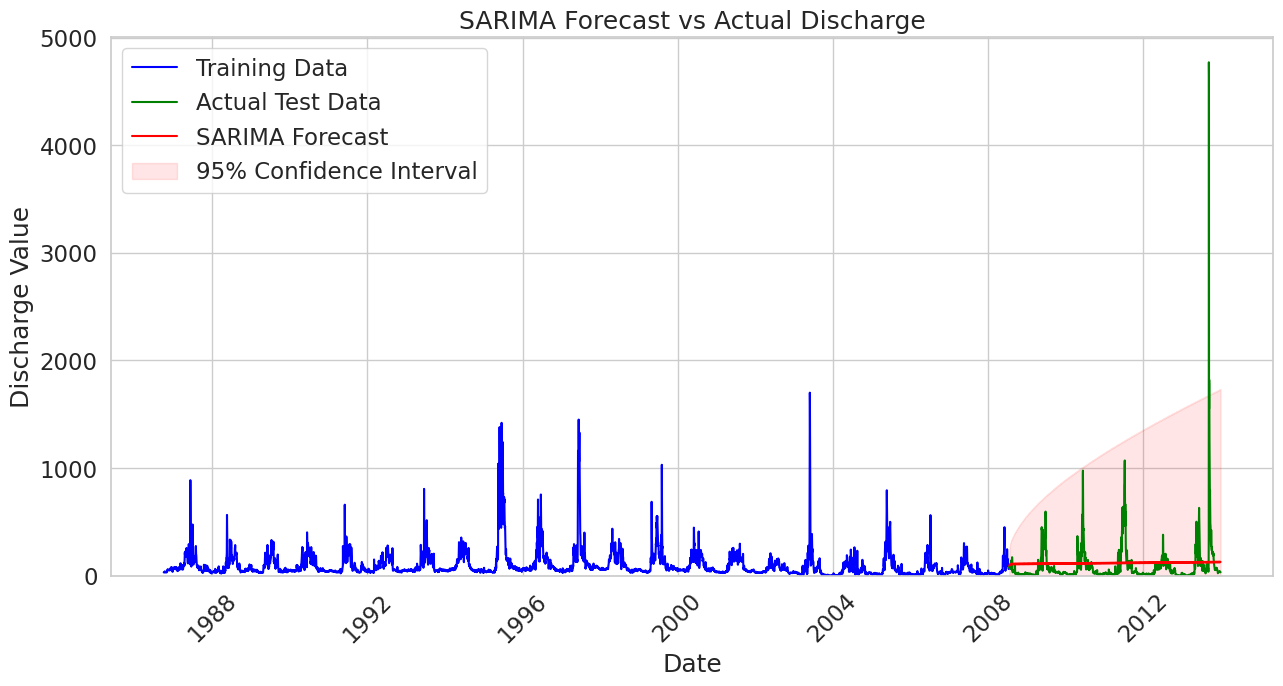

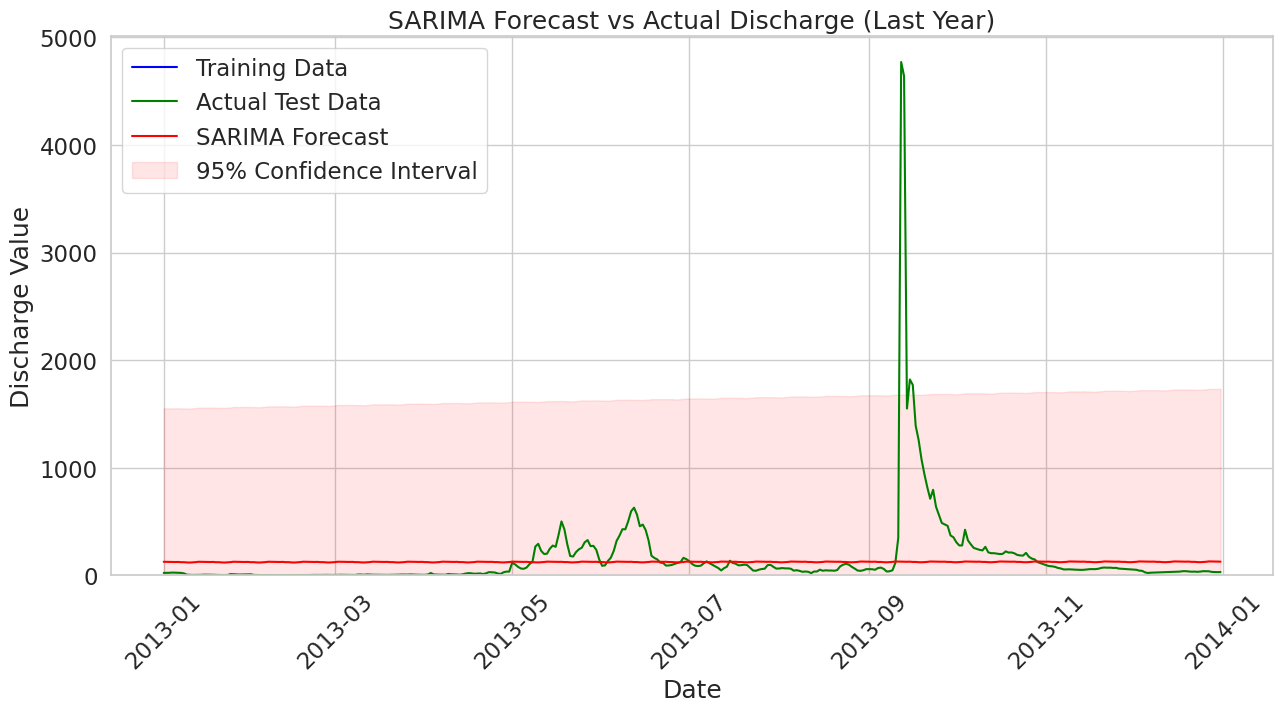

In [7]:
# Earth Data Science Tutorial Blog
# Author: Earth Lab
# Last Updated: April 2024
# Description: Time Series Data Analysis in Python using Pandas and SARIMA

# Import necessary packages
import os
import warnings

import earthpy as et
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

# Handle date time conversions between pandas and matplotlib
from pandas.plotting import register_matplotlib_converters

register_matplotlib_converters()

# Set plot style
sns.set(font_scale=1.5, style="whitegrid")

# Download and set up data
data = et.data.get_data("colorado-flood")
os.chdir(os.path.join(et.io.HOME, "earth-analytics", "data"))

# Define path to discharge data
stream_discharge_path = os.path.join(
    "colorado-flood", "discharge", "06730200-discharge-daily-1986-2013.csv"
)


def process_discharge_data(filepath):
    """Read and process time series data"""
    df = pd.read_csv(filepath)
    df["datetime"] = pd.to_datetime(df["datetime"])
    df.set_index("datetime", inplace=True)
    return df


def plot_discharge(df, title="Stream Discharge Over Time"):
    """Plot time series data"""
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(df.index, df["disValue"])
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Discharge Value")
    # Set y-axis minimum to 0
    ax.set_ylim(bottom=0)
    plt.xticks(rotation=45)
    return fig, ax


def subset_time_period(df, start_date, end_date):
    """Subset data for specific time period"""
    return df.loc[start_date:end_date]


def resample_weekly(df):
    """Resample data to weekly values"""
    return df.resample("W").max()


def save_plot(fig, filename, dpi=300):
    """Save plot to the specified filename with given DPI"""
    if not os.path.exists("plots"):
        os.makedirs("plots")
    fig.savefig(os.path.join("plots", filename), bbox_inches="tight", dpi=dpi)


def fit_sarima_model(
    data, train_size=0.8, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)
):
    """
    Fit SARIMA model and make predictions

    Parameters:
    - order: (p,d,q) for ARIMA
    - seasonal_order: (P,D,Q,s) for seasonal component
    """
    # Split the data
    train_size = int(len(data) * train_size)
    train = data[:train_size]
    test = data[train_size:]

    # Fit SARIMA model
    model = SARIMAX(train["disValue"], order=order, seasonal_order=seasonal_order)
    results = model.fit()

    # Make predictions
    predictions = results.predict(start=len(train), end=len(train) + len(test) - 1)

    return train, test, predictions, results


def plot_sarima_results(
    train, test, predictions, confidence_intervals=None, title="SARIMA Forecast"
):
    """Plot SARIMA results with optional confidence intervals"""
    fig, ax = plt.subplots(figsize=(15, 7))

    # Plot training data
    ax.plot(train.index, train["disValue"], label="Training Data", color="blue")

    # Plot test data
    ax.plot(test.index, test["disValue"], label="Actual Test Data", color="green")

    # Plot predictions
    ax.plot(test.index, predictions, label="SARIMA Forecast", color="red")

    # Plot confidence intervals if provided
    if confidence_intervals is not None:
        # Ensure confidence intervals don't go below 0
        lower_ci = np.maximum(confidence_intervals["lower"], 0)
        ax.fill_between(
            test.index,
            lower_ci,
            confidence_intervals["upper"],
            color="red",
            alpha=0.1,
            label="95% Confidence Interval",
        )

    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Discharge Value")
    # Set y-axis minimum to 0
    ax.set_ylim(bottom=0)
    plt.xticks(rotation=45)
    plt.legend()

    return fig, ax


if __name__ == "__main__":
    # Load data
    print("Loading and processing data...")
    discharge_df = process_discharge_data(stream_discharge_path)

    # Create and save basic plot
    fig1, ax1 = plot_discharge(discharge_df)
    save_plot(fig1, "full_timeseries.png")

    # Subset to flood period
    flood_period = subset_time_period(discharge_df, "2013-08-01", "2013-10-31")

    # Create and save flood period plot
    fig2, ax2 = plot_discharge(
        flood_period, "Stream Discharge During 2013 Colorado Flood"
    )
    save_plot(fig2, "flood_period.png")

    # Resample to weekly data
    weekly_data = resample_weekly(flood_period)

    # Plot and save weekly data
    fig3, ax3 = plot_discharge(weekly_data, "Weekly Maximum Stream Discharge")
    save_plot(fig3, "weekly_discharge.png")

    # Fit SARIMA model
    print("Fitting SARIMA model...")
    train, test, predictions, model_results = fit_sarima_model(
        discharge_df, train_size=0.8, order=(2, 1, 2), seasonal_order=(1, 1, 1, 12)
    )

    # Get forecast confidence intervals
    forecast = model_results.get_forecast(len(test))
    conf_int = forecast.conf_int()
    confidence_intervals = {"lower": conf_int.iloc[:, 0], "upper": conf_int.iloc[:, 1]}

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(test["disValue"], predictions))
    print(f"RMSE: {rmse:.2f}")

    # Plot and save SARIMA results
    fig4, ax4 = plot_sarima_results(
        train,
        test,
        predictions,
        confidence_intervals,
        "SARIMA Forecast vs Actual Discharge",
    )
    save_plot(fig4, "sarima_forecast.png")

    # Create a zoomed version for better visibility
    # Subset last year of data
    last_year = discharge_df.last("365D")
    last_year_train = train[train.index >= last_year.index[0]]
    last_year_test = test[test.index >= last_year.index[0]]
    last_year_pred = predictions[predictions.index >= last_year.index[0]]

    # Get confidence intervals for last year
    last_year_ci = {
        "lower": confidence_intervals["lower"][
            confidence_intervals["lower"].index >= last_year.index[0]
        ],
        "upper": confidence_intervals["upper"][
            confidence_intervals["upper"].index >= last_year.index[0]
        ],
    }

    # Plot and save zoomed SARIMA results
    fig5, ax5 = plot_sarima_results(
        last_year_train,
        last_year_test,
        last_year_pred,
        last_year_ci,
        "SARIMA Forecast vs Actual Discharge (Last Year)",
    )
    save_plot(fig5, "sarima_forecast_zoomed.png")

    # Show all plots
    plt.show()

In [8]:
# Alternative method using NOAA API

import requests


def get_noaa_precip_data(station_id, start_date, end_date, token):
    """
    Fetch precipitation data from NOAA API

    Parameters:
    -----------
    station_id: str, NOAA station identifier
    start_date: str, start date in format 'YYYY-MM-DD'
    end_date: str, end date in format 'YYYY-MM-DD'
    token: str, NOAA API token
    """
    base_url = "https://www.ncdc.noaa.gov/cdo-web/api/v2/data"

    headers = {"token": token}

    params = {
        "datasetid": "GHCND",
        "stationid": station_id,
        "startdate": start_date,
        "enddate": end_date,
        "datatypeid": "PRCP",
        "limit": 1000,
    }

    response = requests.get(base_url, headers=headers, params=params)

    if response.status_code == 200:
        data = response.json()
        df = pd.DataFrame(data["results"])
        df["date"] = pd.to_datetime(df["date"])
        df.set_index("date", inplace=True)
        return df
    else:
        print(f"Error: {response.status_code}")
        return None

Loading and processing discharge data...
Loading and processing precipitation data...
Creating combined discharge and precipitation plot...
Total precipitation during flood period: 17.7 mm


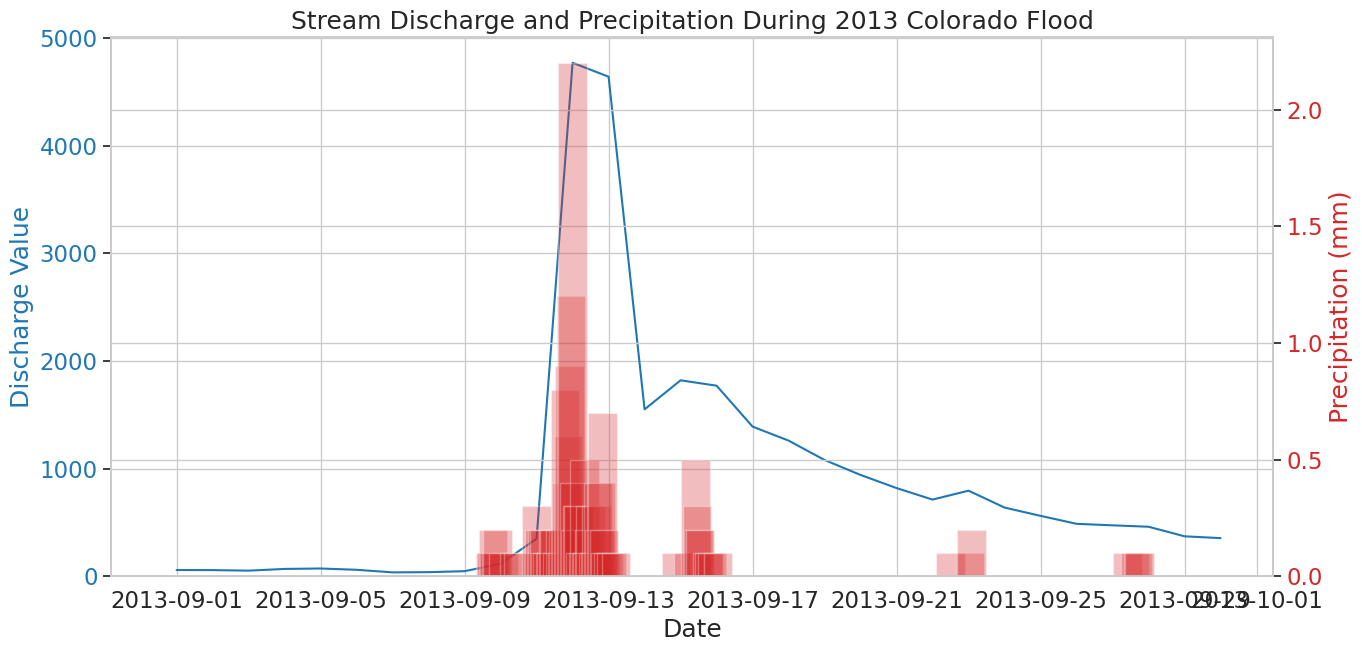

In [9]:
# Add to imports

# Add new data path for precipitation
precip_path = os.path.join(
    "colorado-flood", "precipitation", "805325-precip-daily-2003-2013.csv"
)


def process_precip_data(filepath):
    """Read and process precipitation data"""
    df = pd.read_csv(filepath)
    df["DATE"] = pd.to_datetime(df["DATE"])
    df.set_index("DATE", inplace=True)
    return df


def plot_discharge_and_precip(discharge_df, precip_df, start_date, end_date):
    """
    Plot discharge and precipitation data

    Parameters:
    -----------
    discharge_df: DataFrame with discharge data
    precip_df: DataFrame with precipitation data
    start_date: str, start date for plot
    end_date: str, end date for plot
    """
    # Subset data to desired time period
    discharge_subset = subset_time_period(discharge_df, start_date, end_date)
    precip_subset = subset_time_period(precip_df, start_date, end_date)

    # Create figure with two y-axes
    fig, ax1 = plt.subplots(figsize=(15, 7))

    # Plot discharge on primary y-axis
    color = "tab:blue"
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Discharge Value", color=color)
    ax1.plot(discharge_subset.index, discharge_subset["disValue"], color=color)
    ax1.tick_params(axis="y", labelcolor=color)
    ax1.set_ylim(bottom=0)

    # Create secondary y-axis for precipitation
    ax2 = ax1.twinx()
    color = "tab:red"
    ax2.set_ylabel("Precipitation (mm)", color=color)
    ax2.bar(precip_subset.index, precip_subset["HPCP"], color=color, alpha=0.3)
    ax2.tick_params(axis="y", labelcolor=color)
    ax2.set_ylim(bottom=0)

    # Add title and adjust layout
    plt.title("Stream Discharge and Precipitation During 2013 Colorado Flood")
    plt.xticks(rotation=45)

    return fig, (ax1, ax2)


# Modify main block to include precipitation analysis
if __name__ == "__main__":
    # Load discharge data
    print("Loading and processing discharge data...")
    discharge_df = process_discharge_data(stream_discharge_path)

    # Load precipitation data
    print("Loading and processing precipitation data...")
    precip_df = process_precip_data(precip_path)

    # Create combined plot for flood period
    print("Creating combined discharge and precipitation plot...")
    fig6, axes = plot_discharge_and_precip(
        discharge_df, precip_df, "2013-09-01", "2013-09-30"
    )
    save_plot(fig6, "discharge_and_precip_flood.png")

    # Calculate total precipitation during flood period
    flood_precip = precip_df.loc["2013-09-01":"2013-09-30", "HPCP"].sum()
    print(f"Total precipitation during flood period: {flood_precip:.1f} mm")

    # Previous code remains the same...

Loading and processing data...

Flood Metrics:
total_precip: 17.700000000000003
max_discharge: 4770.0
mean_discharge: 861.4666666666667
max_precip_day: 2013-09-12 00:00:00
max_discharge_day: 2013-09-12 00:00:00

Generating plots...

Fitting SARIMA model...
RMSE: 210.63


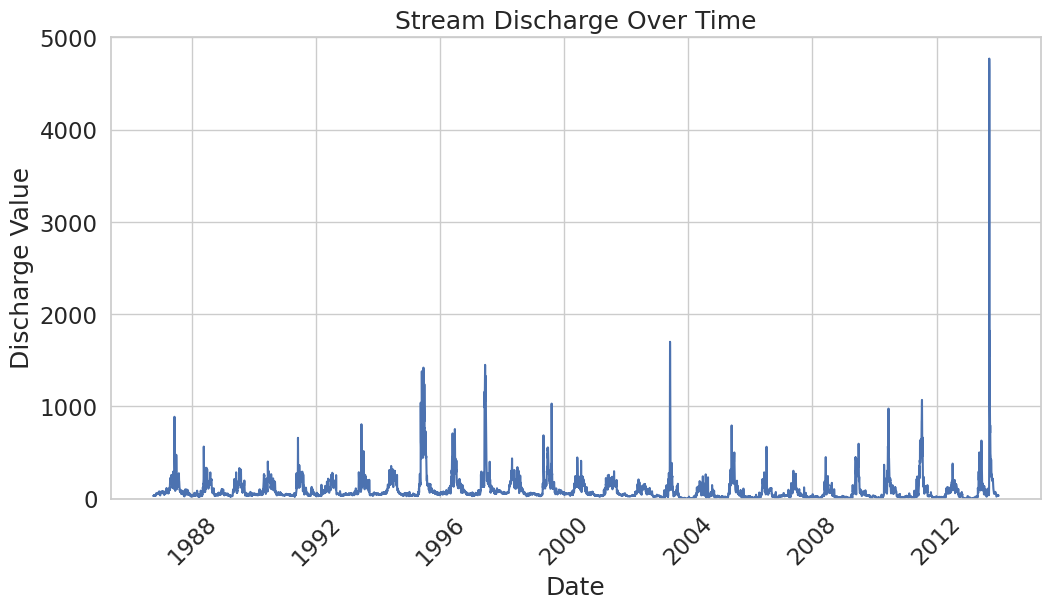

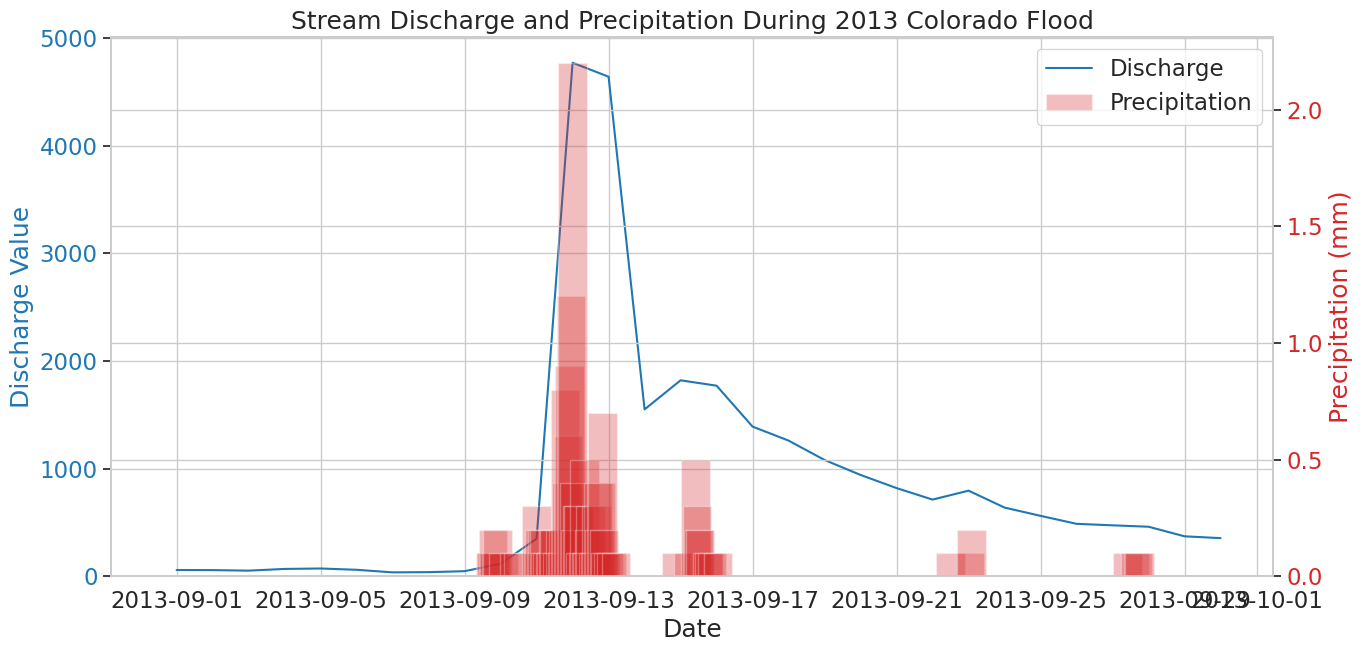

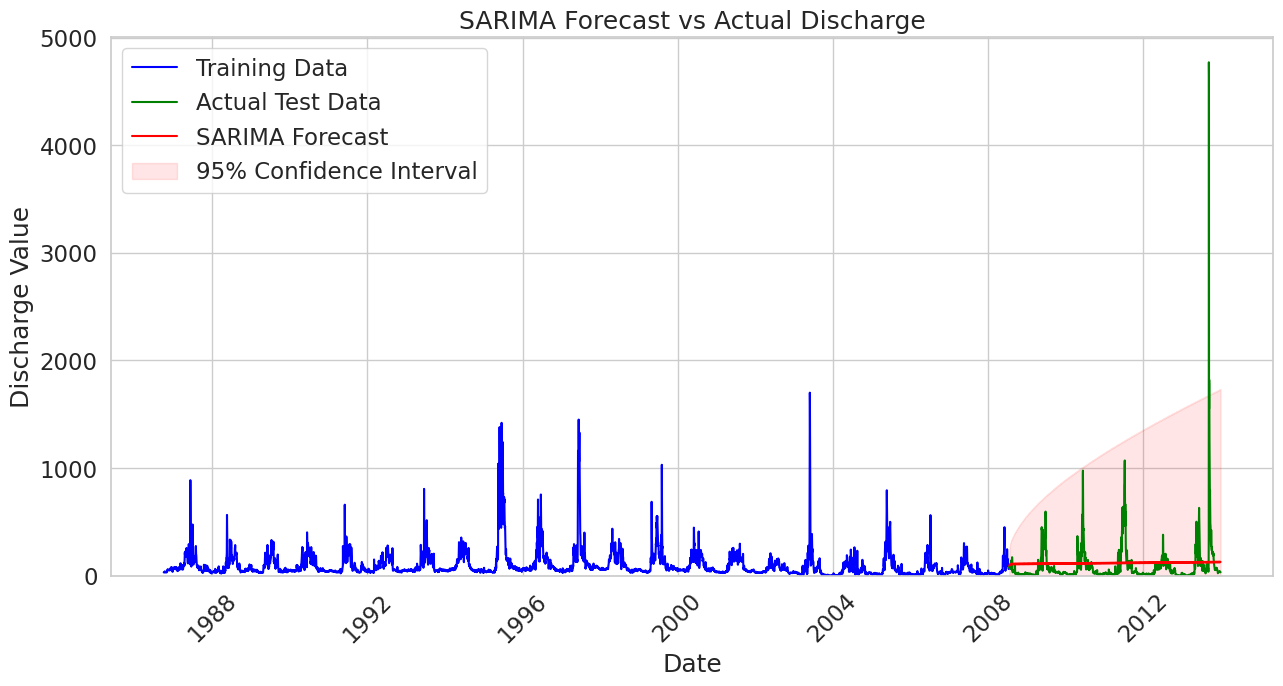

In [10]:
# Earth Data Science Tutorial Blog
# Author: Earth Lab
# Last Updated: April 2024
# Description: Time Series Analysis of 2013 Colorado Flood

import os
import warnings

import earthpy as et
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")

# Handle date time conversions
from pandas.plotting import register_matplotlib_converters

register_matplotlib_converters()

# Set plot style
sns.set(font_scale=1.5, style="whitegrid")

# Download and set up data
data = et.data.get_data("colorado-flood")
os.chdir(os.path.join(et.io.HOME, "earth-analytics", "data"))

# Define paths
stream_discharge_path = os.path.join(
    "colorado-flood", "discharge", "06730200-discharge-daily-1986-2013.csv"
)
precip_path = os.path.join(
    "colorado-flood", "precipitation", "805325-precip-daily-2003-2013.csv"
)


# Data processing functions
def process_discharge_data(filepath):
    """Read and process discharge data"""
    df = pd.read_csv(filepath)
    df["datetime"] = pd.to_datetime(df["datetime"])
    df.set_index("datetime", inplace=True)
    return df


def process_precip_data(filepath):
    """Read and process precipitation data"""
    df = pd.read_csv(filepath)
    df["DATE"] = pd.to_datetime(df["DATE"])
    df.set_index("DATE", inplace=True)
    return df


# Plotting functions
def plot_discharge(df, title="Stream Discharge Over Time"):
    """Plot discharge time series"""
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(df.index, df["disValue"])
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Discharge Value")
    ax.set_ylim(bottom=0)
    plt.xticks(rotation=45)
    return fig, ax


def plot_discharge_and_precip(discharge_df, precip_df, start_date, end_date):
    """Plot combined discharge and precipitation"""
    discharge_subset = subset_time_period(discharge_df, start_date, end_date)
    precip_subset = subset_time_period(precip_df, start_date, end_date)

    fig, ax1 = plt.subplots(figsize=(15, 7))

    # Discharge on primary y-axis
    color = "tab:blue"
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Discharge Value", color=color)
    ax1.plot(
        discharge_subset.index,
        discharge_subset["disValue"],
        color=color,
        label="Discharge",
    )
    ax1.tick_params(axis="y", labelcolor=color)
    ax1.set_ylim(bottom=0)

    # Precipitation on secondary y-axis
    ax2 = ax1.twinx()
    color = "tab:red"
    ax2.set_ylabel("Precipitation (mm)", color=color)
    ax2.bar(
        precip_subset.index,
        precip_subset["HPCP"],
        color=color,
        alpha=0.3,
        label="Precipitation",
    )
    ax2.tick_params(axis="y", labelcolor=color)
    ax2.set_ylim(bottom=0)

    # Title and layout
    plt.title("Stream Discharge and Precipitation During 2013 Colorado Flood")
    plt.xticks(rotation=45)

    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    return fig, (ax1, ax2)


def plot_sarima_results(
    train, test, predictions, confidence_intervals=None, title="SARIMA Forecast"
):
    """Plot SARIMA results with confidence intervals"""
    fig, ax = plt.subplots(figsize=(15, 7))

    ax.plot(train.index, train["disValue"], label="Training Data", color="blue")
    ax.plot(test.index, test["disValue"], label="Actual Test Data", color="green")
    ax.plot(test.index, predictions, label="SARIMA Forecast", color="red")

    if confidence_intervals is not None:
        lower_ci = np.maximum(confidence_intervals["lower"], 0)
        ax.fill_between(
            test.index,
            lower_ci,
            confidence_intervals["upper"],
            color="red",
            alpha=0.1,
            label="95% Confidence Interval",
        )

    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Discharge Value")
    ax.set_ylim(bottom=0)
    plt.xticks(rotation=45)
    plt.legend()

    return fig, ax


# Analysis functions
def subset_time_period(df, start_date, end_date):
    """Subset data for specific time period"""
    return df.loc[start_date:end_date]


def resample_weekly(df):
    """Resample data to weekly values"""
    return df.resample("W").max()


def fit_sarima_model(
    data, train_size=0.8, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)
):
    """Fit SARIMA model and make predictions"""
    train_size = int(len(data) * train_size)
    train = data[:train_size]
    test = data[train_size:]

    model = SARIMAX(train["disValue"], order=order, seasonal_order=seasonal_order)
    results = model.fit()

    predictions = results.predict(start=len(train), end=len(train) + len(test) - 1)

    return train, test, predictions, results


def save_plot(fig, filename, dpi=300):
    """Save plot to file"""
    if not os.path.exists("plots"):
        os.makedirs("plots")
    fig.savefig(os.path.join("plots", filename), bbox_inches="tight", dpi=dpi)


def analyze_flood_metrics(discharge_df, precip_df, flood_start, flood_end):
    """Calculate key flood metrics"""
    flood_discharge = subset_time_period(discharge_df, flood_start, flood_end)
    flood_precip = subset_time_period(precip_df, flood_start, flood_end)

    metrics = {
        "total_precip": flood_precip["HPCP"].sum(),
        "max_discharge": flood_discharge["disValue"].max(),
        "mean_discharge": flood_discharge["disValue"].mean(),
        "max_precip_day": flood_precip["HPCP"].idxmax(),
        "max_discharge_day": flood_discharge["disValue"].idxmax(),
    }

    return metrics


if __name__ == "__main__":
    # Load data
    print("Loading and processing data...")
    discharge_df = process_discharge_data(stream_discharge_path)
    precip_df = process_precip_data(precip_path)

    # Analyze flood period
    flood_metrics = analyze_flood_metrics(
        discharge_df, precip_df, "2013-09-01", "2013-09-30"
    )
    print("\nFlood Metrics:")
    for key, value in flood_metrics.items():
        print(f"{key}: {value}")

    # Create all plots
    print("\nGenerating plots...")

    # Basic discharge plot
    fig1, ax1 = plot_discharge(discharge_df)
    save_plot(fig1, "full_timeseries.png")

    # Flood period combined plot
    fig2, axes2 = plot_discharge_and_precip(
        discharge_df, precip_df, "2013-09-01", "2013-09-30"
    )
    save_plot(fig2, "flood_period_combined.png")

    # SARIMA modeling
    print("\nFitting SARIMA model...")
    train, test, predictions, model_results = fit_sarima_model(
        discharge_df, train_size=0.8, order=(2, 1, 2), seasonal_order=(1, 1, 1, 12)
    )

    # Get forecast confidence intervals
    forecast = model_results.get_forecast(len(test))
    conf_int = forecast.conf_int()
    confidence_intervals = {"lower": conf_int.iloc[:, 0], "upper": conf_int.iloc[:, 1]}

    # Calculate and print RMSE
    rmse = np.sqrt(mean_squared_error(test["disValue"], predictions))
    print(f"RMSE: {rmse:.2f}")

    # Plot SARIMA results
    fig3, ax3 = plot_sarima_results(
        train,
        test,
        predictions,
        confidence_intervals,
        "SARIMA Forecast vs Actual Discharge",
    )
    save_plot(fig3, "sarima_forecast.png")

    plt.show()


Creating animation...



Creating animation: 100%|██████████| 30/30 [00:10<00:00,  4.09it/s]
Creating animation: 31it [00:15,  2.05it/s]


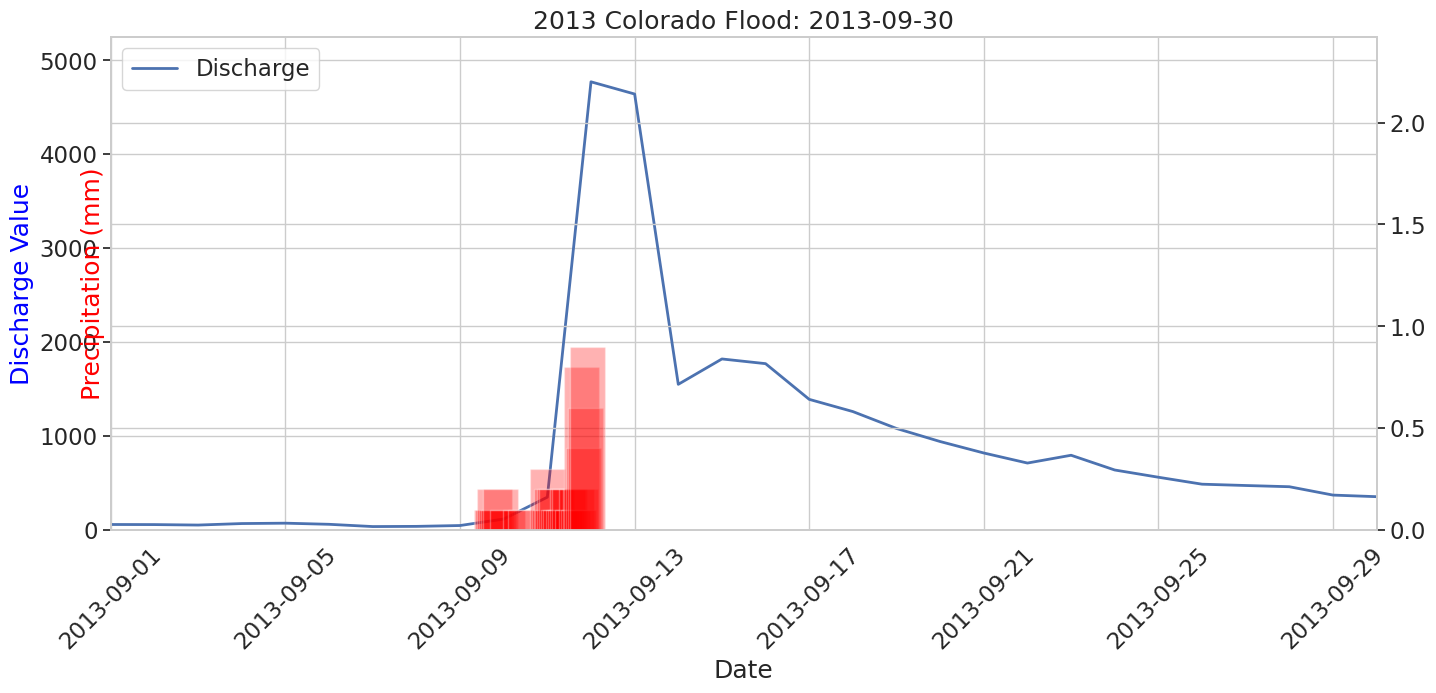

In [12]:
# Add these imports at the top
from matplotlib.animation import FuncAnimation, PillowWriter
from tqdm import tqdm


def create_animated_plot(
    discharge_df,
    precip_df,
    start_date,
    end_date,
    interval=100,
    save_path="flood_animation.gif",
):
    """
    Create an animated plot showing discharge and precipitation over time
    with progress bar
    """
    # Subset data
    discharge_subset = subset_time_period(discharge_df, start_date, end_date)
    precip_subset = subset_time_period(precip_df, start_date, end_date)

    # Create figure and axes
    fig, ax1 = plt.subplots(figsize=(15, 7))
    ax2 = ax1.twinx()

    # Set up line objects
    (discharge_line,) = ax1.plot([], [], "b-", label="Discharge", linewidth=2)

    # Set up axes
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Discharge Value", color="blue")
    ax2.set_ylabel("Precipitation (mm)", color="red")

    # Set limits
    ax1.set_xlim(discharge_subset.index[0], discharge_subset.index[-1])
    ax1.set_ylim(0, discharge_subset["disValue"].max() * 1.1)
    ax2.set_ylim(0, precip_subset["HPCP"].max() * 1.1)

    # Set up date formatting
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

    # Combine legends
    ax1.legend(["Discharge"], loc="upper left")
    ax2.legend(["Precipitation"], loc="upper right")

    # Tight layout
    plt.tight_layout()

    def animate(frame):
        """Animation function"""
        # Clear previous precipitation bars
        ax2.clear()
        ax2.set_ylabel("Precipitation (mm)", color="red")
        ax2.set_ylim(0, precip_subset["HPCP"].max() * 1.1)

        # Update discharge line
        current_date = discharge_subset.index[frame]
        dates = discharge_subset.index[: frame + 1]
        discharge_values = discharge_subset["disValue"][: frame + 1]
        discharge_line.set_data(dates, discharge_values)

        # Update precipitation bars
        ax2.bar(
            precip_subset.index[: frame + 1],
            precip_subset["HPCP"][: frame + 1],
            color="red",
            alpha=0.3,
        )

        # Update title with current date
        plt.title(f"2013 Colorado Flood: {current_date.strftime('%Y-%m-%d')}")

        # Update progress bar
        pbar.update(1)

        return (discharge_line,)

    # Set up progress bar
    pbar = tqdm(total=len(discharge_subset), desc="Creating animation")

    # Create animation
    anim = FuncAnimation(
        fig, animate, frames=len(discharge_subset), interval=interval, blit=False
    )

    # Set up GIF writer
    writer = PillowWriter(fps=30)

    # Save animation as GIF
    if not os.path.exists("plots"):
        os.makedirs("plots")
    anim.save(os.path.join("plots", save_path), writer=writer)

    # Close progress bar
    pbar.close()

    return anim


# Add to main block:
if __name__ == "__main__":
    # Previous code remains...

    # Create animation
    print("\nCreating animation...")
    anim = create_animated_plot(
        discharge_df,
        precip_df,
        "2013-09-01",
        "2013-09-30",
        interval=50,  # Faster animation
        save_path="flood_animation.gif",
    )

    plt.show()


Creating animation...



Creating animation: 100%|██████████| 30/30 [00:09<00:00,  4.26it/s]
Creating animation: 31it [00:14,  2.11it/s]


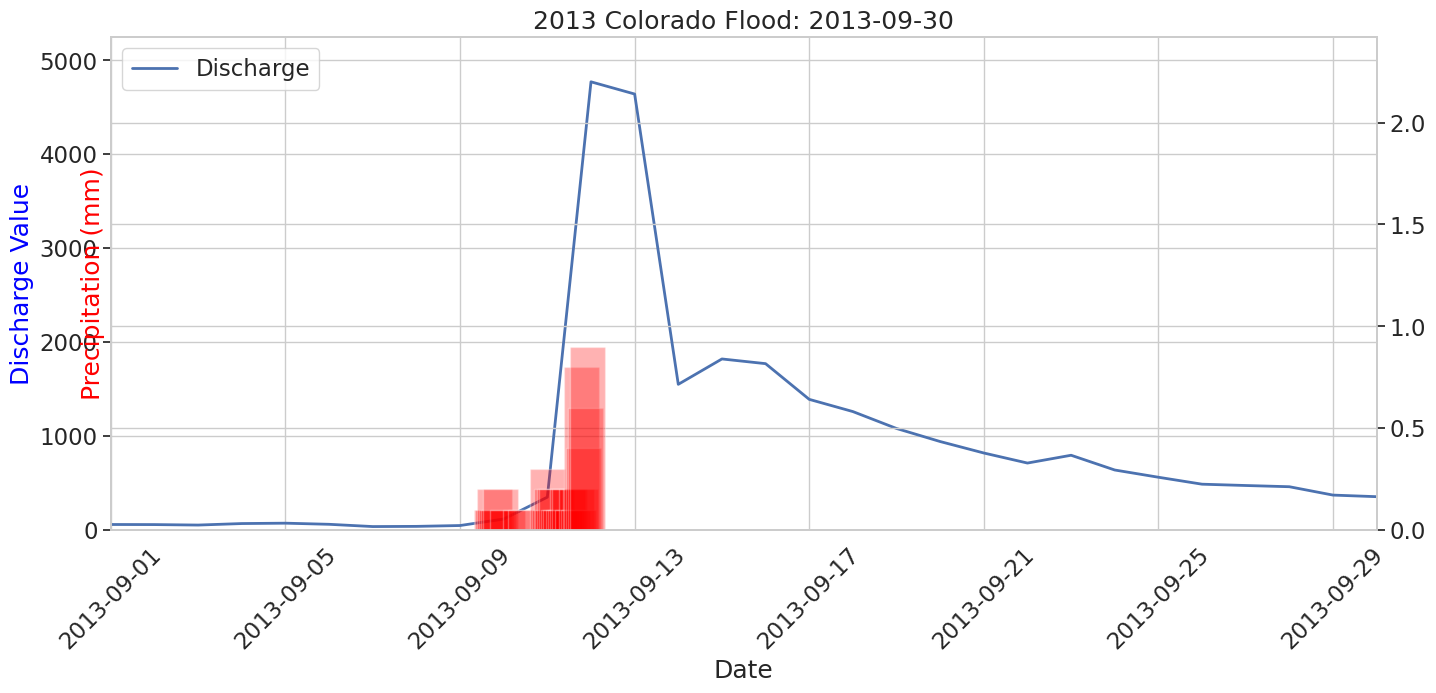

In [13]:
# Add these imports at the top


def create_animated_plot(
    discharge_df,
    precip_df,
    start_date,
    end_date,
    interval=100,
    save_path="flood_animation.gif",
):
    """
    Create an animated plot showing discharge and precipitation over time
    with progress bar
    """
    # Subset data
    discharge_subset = subset_time_period(discharge_df, start_date, end_date)
    precip_subset = subset_time_period(precip_df, start_date, end_date)

    # Create figure and axes
    fig, ax1 = plt.subplots(figsize=(15, 7))
    ax2 = ax1.twinx()

    # Set up line objects
    (discharge_line,) = ax1.plot([], [], "b-", label="Discharge", linewidth=2)

    # Set up axes
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Discharge Value", color="blue")
    ax2.set_ylabel("Precipitation (mm)", color="red")

    # Set limits
    ax1.set_xlim(discharge_subset.index[0], discharge_subset.index[-1])
    ax1.set_ylim(0, discharge_subset["disValue"].max() * 1.1)
    ax2.set_ylim(0, precip_subset["HPCP"].max() * 1.1)

    # Set up date formatting
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

    # Combine legends
    ax1.legend(["Discharge"], loc="upper left")
    ax2.legend(["Precipitation"], loc="upper right")

    # Tight layout
    plt.tight_layout()

    def animate(frame):
        """Animation function"""
        # Clear previous precipitation bars
        ax2.clear()
        ax2.set_ylabel("Precipitation (mm)", color="red")
        ax2.set_ylim(0, precip_subset["HPCP"].max() * 1.1)

        # Update discharge line
        current_date = discharge_subset.index[frame]
        dates = discharge_subset.index[: frame + 1]
        discharge_values = discharge_subset["disValue"][: frame + 1]
        discharge_line.set_data(dates, discharge_values)

        # Update precipitation bars
        ax2.bar(
            precip_subset.index[: frame + 1],
            precip_subset["HPCP"][: frame + 1],
            color="red",
            alpha=0.3,
        )

        # Update title with current date
        plt.title(f"2013 Colorado Flood: {current_date.strftime('%Y-%m-%d')}")

        # Update progress bar
        pbar.update(1)

        return (discharge_line,)

    # Set up progress bar
    pbar = tqdm(total=len(discharge_subset), desc="Creating animation")

    # Create animation
    anim = FuncAnimation(
        fig, animate, frames=len(discharge_subset), interval=interval, blit=False
    )

    # Set up GIF writer
    writer = PillowWriter(fps=30)

    # Save animation directly to current directory
    anim.save(save_path, writer=writer)

    # Close progress bar
    pbar.close()

    return anim


# Add to main block:
if __name__ == "__main__":
    # Previous code remains...

    # Create animation
    print("\nCreating animation...")
    anim = create_animated_plot(
        discharge_df,
        precip_df,
        "2013-09-01",
        "2013-09-30",
        interval=50,  # Faster animation
        save_path="flood_animation.gif",  # Saves in current directory
    )

    plt.show()


Creating animation...



Creating animation: 100%|██████████| 30/30 [00:11<00:00,  4.06it/s]
Creating animation: 31it [00:16,  1.93it/s]


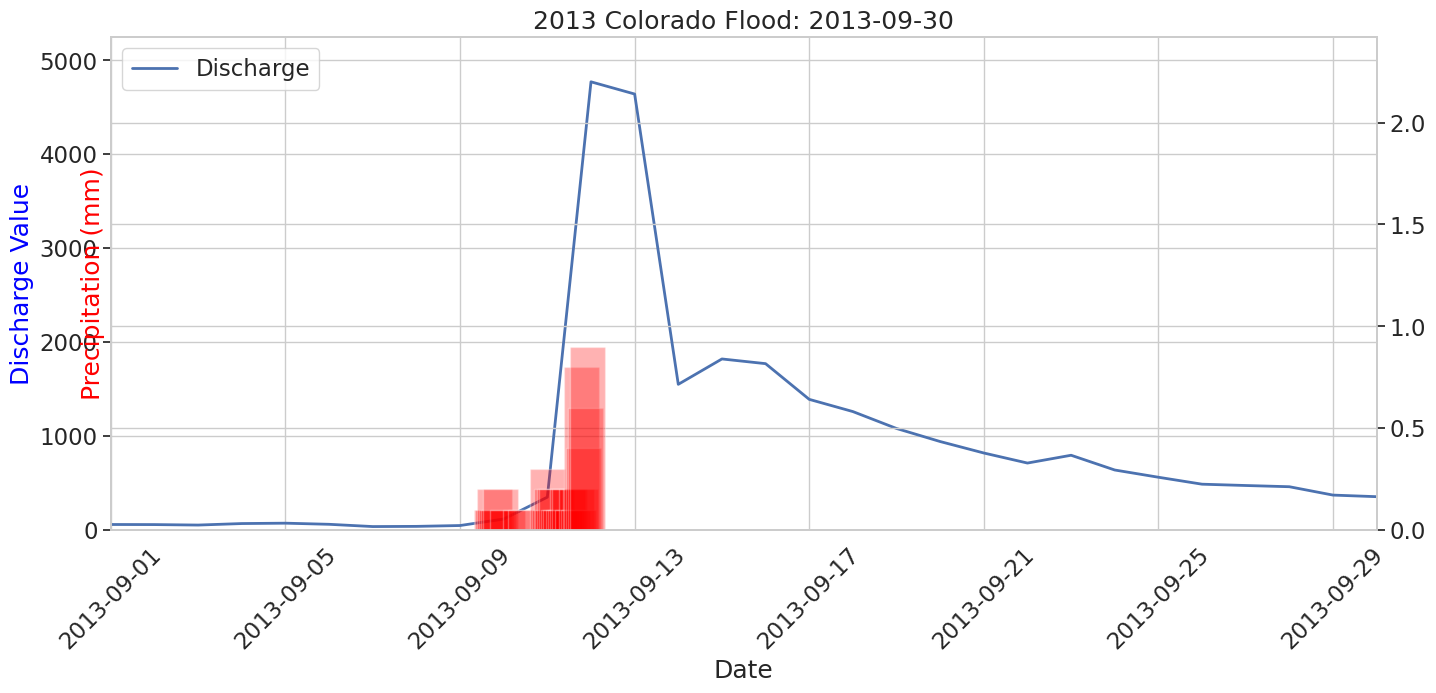

In [14]:
# Add these imports at the top


def create_animated_plot(
    discharge_df,
    precip_df,
    start_date,
    end_date,
    interval=100,
    save_path="flood_animation.gif",
):
    """
    Create an animated plot showing discharge and precipitation over time
    with progress bar
    """
    # Subset data
    discharge_subset = subset_time_period(discharge_df, start_date, end_date)
    precip_subset = subset_time_period(precip_df, start_date, end_date)

    # Create figure and axes
    fig, ax1 = plt.subplots(figsize=(15, 7))
    ax2 = ax1.twinx()

    # Set up line objects
    (discharge_line,) = ax1.plot([], [], "b-", label="Discharge", linewidth=2)

    # Set up axes
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Discharge Value", color="blue")
    ax2.set_ylabel("Precipitation (mm)", color="red")

    # Set limits
    ax1.set_xlim(discharge_subset.index[0], discharge_subset.index[-1])
    ax1.set_ylim(0, discharge_subset["disValue"].max() * 1.1)
    ax2.set_ylim(0, precip_subset["HPCP"].max() * 1.1)

    # Set up date formatting
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

    # Combine legends
    ax1.legend(["Discharge"], loc="upper left")
    ax2.legend(["Precipitation"], loc="upper right")

    # Tight layout
    plt.tight_layout()

    def animate(frame):
        """Animation function"""
        # Clear previous precipitation bars
        ax2.clear()
        ax2.set_ylabel("Precipitation (mm)", color="red")
        ax2.set_ylim(0, precip_subset["HPCP"].max() * 1.1)

        # Update discharge line
        current_date = discharge_subset.index[frame]
        dates = discharge_subset.index[: frame + 1]
        discharge_values = discharge_subset["disValue"][: frame + 1]
        discharge_line.set_data(dates, discharge_values)

        # Update precipitation bars
        ax2.bar(
            precip_subset.index[: frame + 1],
            precip_subset["HPCP"][: frame + 1],
            color="red",
            alpha=0.3,
        )

        # Update title with current date
        plt.title(f"2013 Colorado Flood: {current_date.strftime('%Y-%m-%d')}")

        # Update progress bar
        pbar.update(1)

        return (discharge_line,)

    # Set up progress bar
    pbar = tqdm(total=len(discharge_subset), desc="Creating animation")

    # Create animation
    anim = FuncAnimation(
        fig, animate, frames=len(discharge_subset), interval=interval, blit=False
    )

    # Set up GIF writer
    writer = PillowWriter(fps=30)

    # Save animation directly to current directory
    anim.save(save_path, writer=writer)

    # Close progress bar
    pbar.close()

    return anim


# Add to main block:
if __name__ == "__main__":
    # Previous code remains...

    # Create animation
    print("\nCreating animation...")
    anim = create_animated_plot(
        discharge_df,
        precip_df,
        "2013-09-01",
        "2013-09-30",
        interval=50,  # Faster animation
        save_path="flood_animation.gif",  # Saves in current directory
    )

    plt.show()